Anggota Kelompok :

1. Zahra Dhita Aisyah Putri (24523262)
2. Sifa Aulia Aroyaningrum (24523078)

1. Persiapan Lingkungan dan Instalasi Library

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib gradio kagglehub

# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Library untuk Supervised Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Library untuk menyimpan dan memuat model
import joblib

# Library untuk Gradio
import gradio as gr

# Set style visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!



# 2. Deskripsi Dataset

Nama Dataset: Obesity Prediction Dataset
Sumber: Kaggle (https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset)
Jumlah Data: 2111 baris
Jumlah Fitur: 17 fitur (termasuk target)

Fitur Input (X):
1. Gender: Jenis kelamin (Female/Male)
2. Age: Usia (tahun)
3. Height: Tinggi badan (meter)
4. Weight: Berat badan (kg)
5. family_history_with_overweight: Riwayat keluarga dengan kelebihan berat badan (yes/no)
6. FAVC: Konsumsi makanan tinggi kalori secara sering (yes/no)
7. FCVC: Frekuensi konsumsi sayuran (1-3)
8. NCP: Jumlah makanan utama per hari (1-4)
9. CAEC: Konsumsi makanan di antara waktu makan (Sometimes/Frequently/Always/no)
10. SMOKE: Kebiasaan merokok (yes/no)
11. CH2O: Konsumsi air harian (1-3)
12. SCC: Pemantauan asupan kalori (yes/no)
13. FAF: Frekuensi aktivitas fisik (0-3)
14. TUE: Waktu penggunaan perangkat elektronik (0-2)
15. CALC: Konsumsi alkohol (no/Sometimes/Frequently/Always)
16. MTRANS: Moda transportasi yang digunakan (Automobile/Bike/Motorbike/Public_Transportation/Walking)

Target (y):
- NObeyesdad: Tingkat obesitas (Insufficient_Weight, Normal_Weight, Overweight_Level_I,
  Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III)

Tujuan Analisis: Membangun model klasifikasi untuk memprediksi tingkat obesitas seseorang
berdasarkan faktor-faktor gaya hidup dan demografis.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "ObesityDataSet_raw_and_data_sinthetic.csv"

# Load dataset
df_obesity = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "adeniranstephen/obesity-prediction-dataset",
    file_path,
)

print("="*80)
print("STUDI KASUS 1: SUPERVISED LEARNING - OBESITY PREDICTION")
print("="*80)
print("\nInformasi Dataset:")
print(f"Jumlah data: {df_obesity.shape[0]} baris")
print(f"Jumlah fitur: {df_obesity.shape[1]} kolom")
print("\n5 data teratas:")
display(df_obesity.head())

print("\nInformasi tipe data:")
print(df_obesity.info())

print("\nStatistik deskriptif fitur numerik:")
display(df_obesity.describe())

print("\nDistribusi target (tingkat obesitas):")
print(df_obesity['NObeyesdad'].value_counts())

Using Colab cache for faster access to the 'obesity-prediction-dataset' dataset.
STUDI KASUS 1: SUPERVISED LEARNING - OBESITY PREDICTION

Informasi Dataset:
Jumlah data: 2111 baris
Jumlah fitur: 17 kolom

5 data teratas:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Informasi tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF         

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.418986,2.685651,2.008053,1.010313,0.657861
std,6.357078,0.093368,26.191163,0.533996,0.778079,0.612950,0.850613,0.608926
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.470000,2.000000,2.660000,1.585000,0.125000,0.000000
50%,23.000000,1.700000,83.000000,2.390000,3.000000,2.000000,1.000000,0.625000
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.480000,1.670000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Distribusi target (tingkat obesitas):
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


3. Exploratory Data Analysis (EDA) dan Visualisasi Data

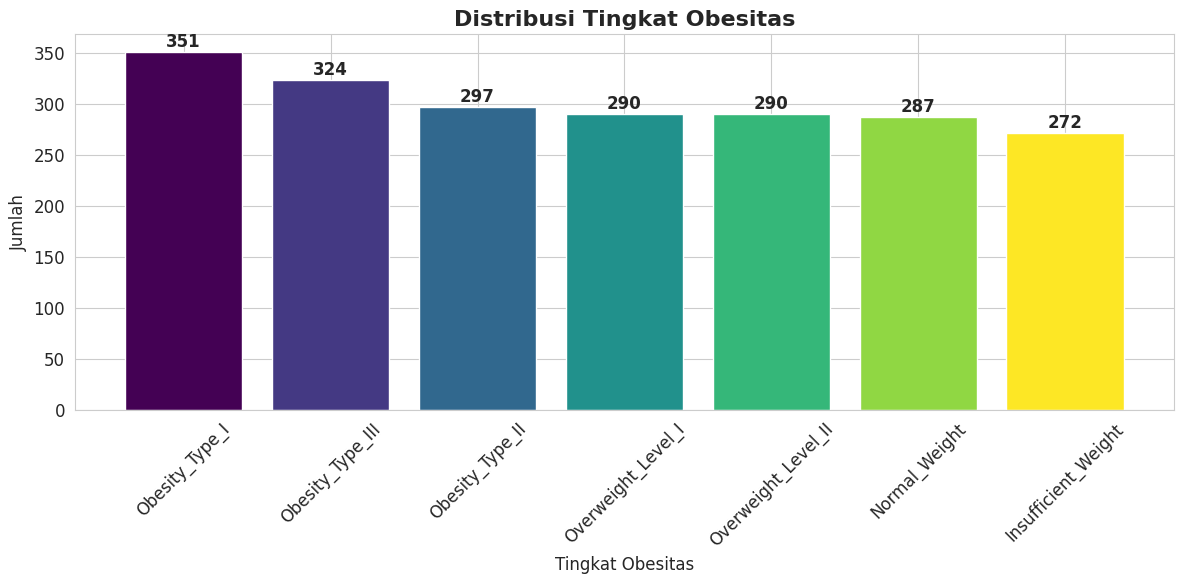

In [ ]:
# 3.1 Distribusi Target
plt.figure(figsize=(12, 6))
target_counts = df_obesity['NObeyesdad'].value_counts()
colors = plt.cm.viridis(np.linspace(0, 1, len(target_counts)))
bars = plt.bar(target_counts.index, target_counts.values, color=colors)
plt.title('Distribusi Tingkat Obesitas', fontsize=16, fontweight='bold')
plt.xlabel('Tingkat Obesitas')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
for bar, v in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

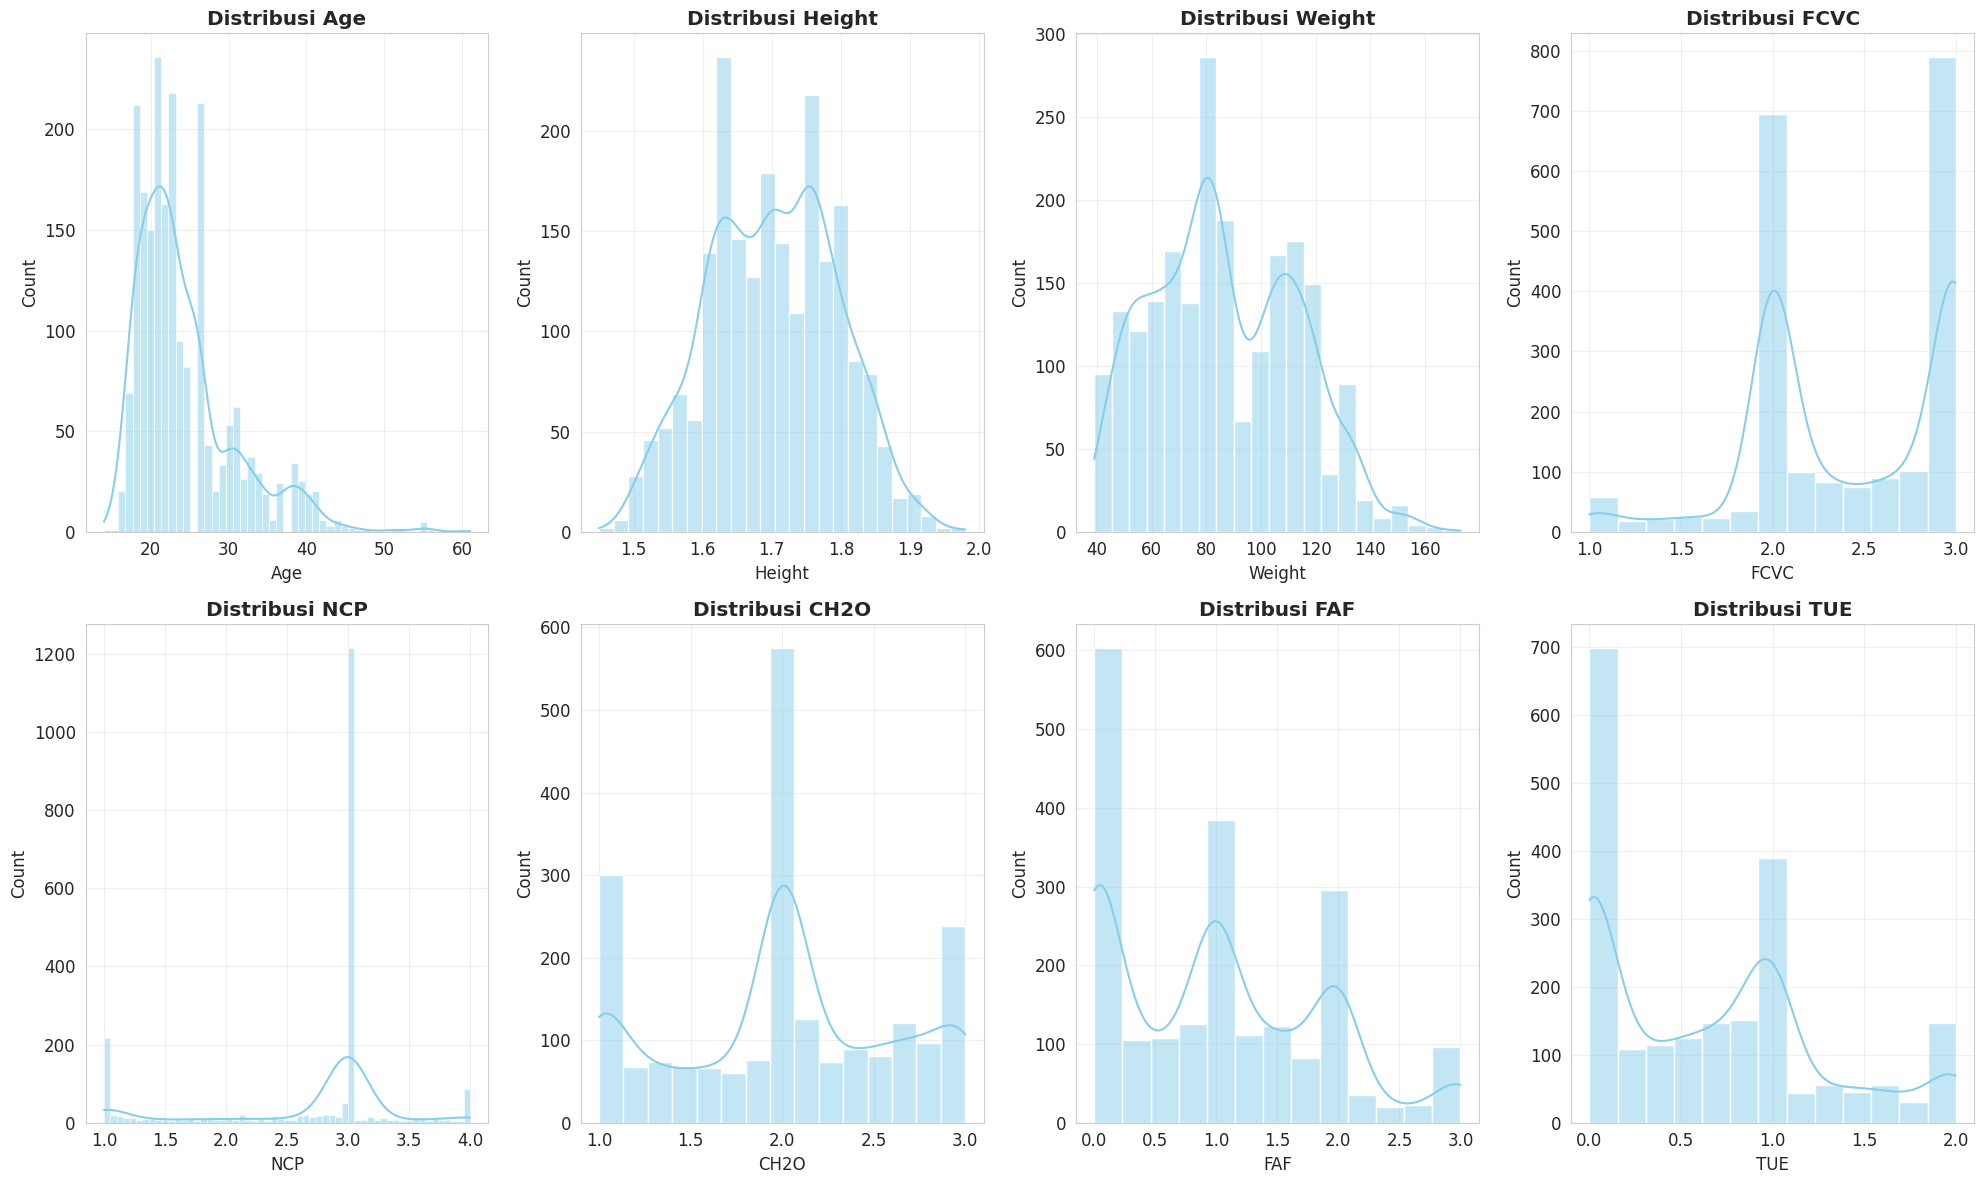

In [ ]:
  # 3.2 Distribusi Fitur Numerik
  numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
  fig, axes = plt.subplots(2, 4, figsize=(20, 12))
  axes = axes.flatten()

  for idx, col in enumerate(numerical_cols):
      sns.histplot(df_obesity[col], kde=True, ax=axes[idx], color='skyblue')
      axes[idx].set_title(f'Distribusi {col}', fontweight='bold')
      axes[idx].set_xlabel(col)
      axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

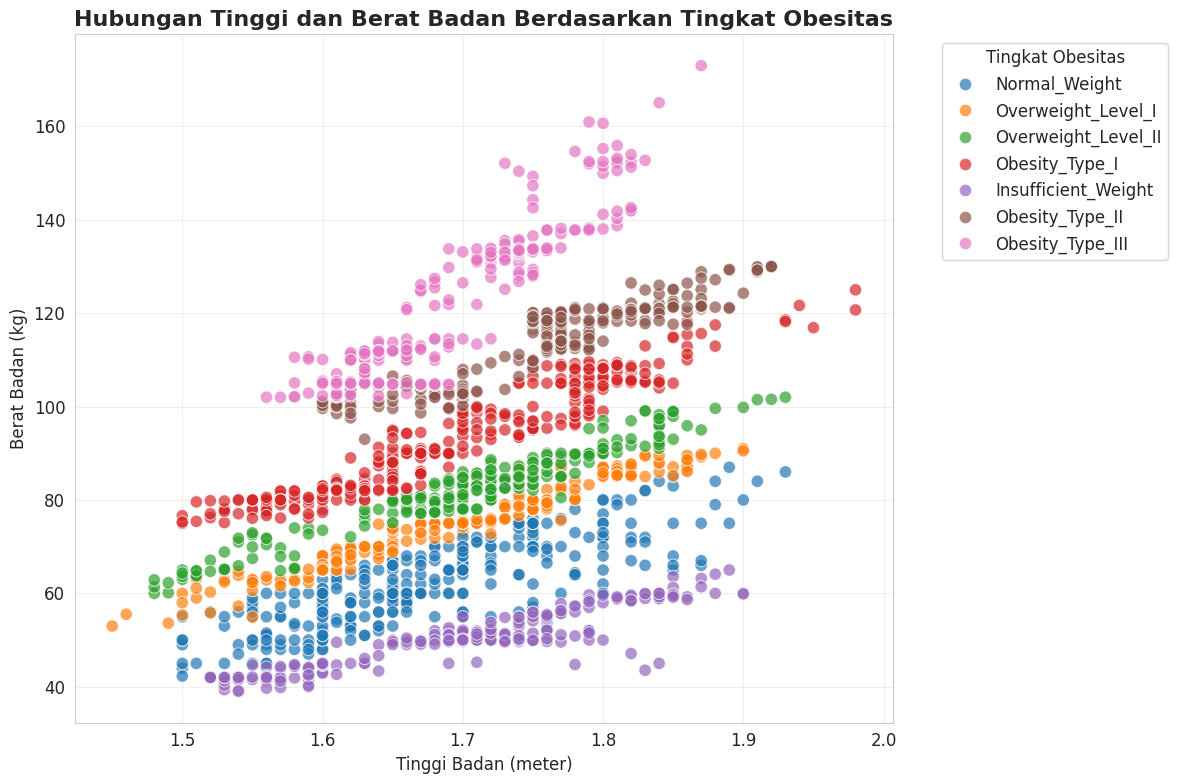

In [ ]:
# 3.3 Hubungan Antara Berat Badan dan Tinggi Badan Berdasarkan Tingkat Obesitas
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=df_obesity, x='Height', y='Weight',
                         hue='NObeyesdad', palette='tab10', alpha=0.7, s=80)
plt.title('Hubungan Tinggi dan Berat Badan Berdasarkan Tingkat Obesitas',
          fontsize=16, fontweight='bold')
plt.xlabel('Tinggi Badan (meter)')
plt.ylabel('Berat Badan (kg)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tingkat Obesitas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

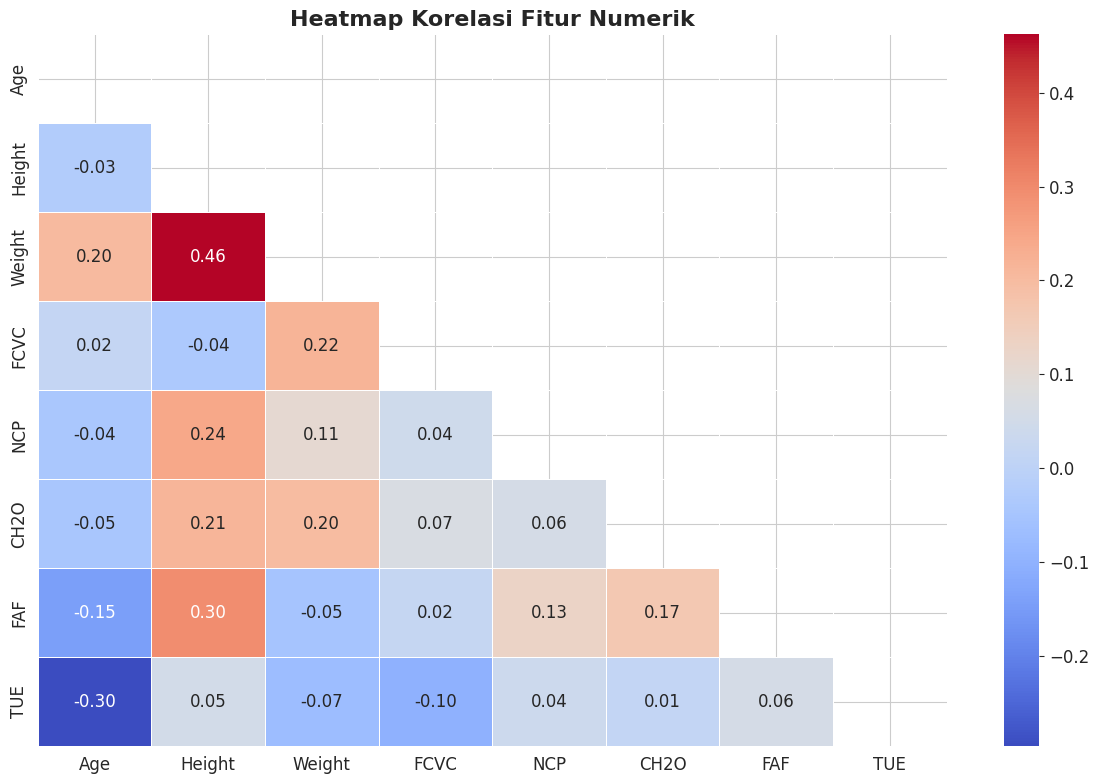

In [ ]:
# 3.4 Korelasi Antar Fitur Numerik
plt.figure(figsize=(12, 8))
correlation = df_obesity[numerical_cols].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5,
            fmt='.2f', mask=mask)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

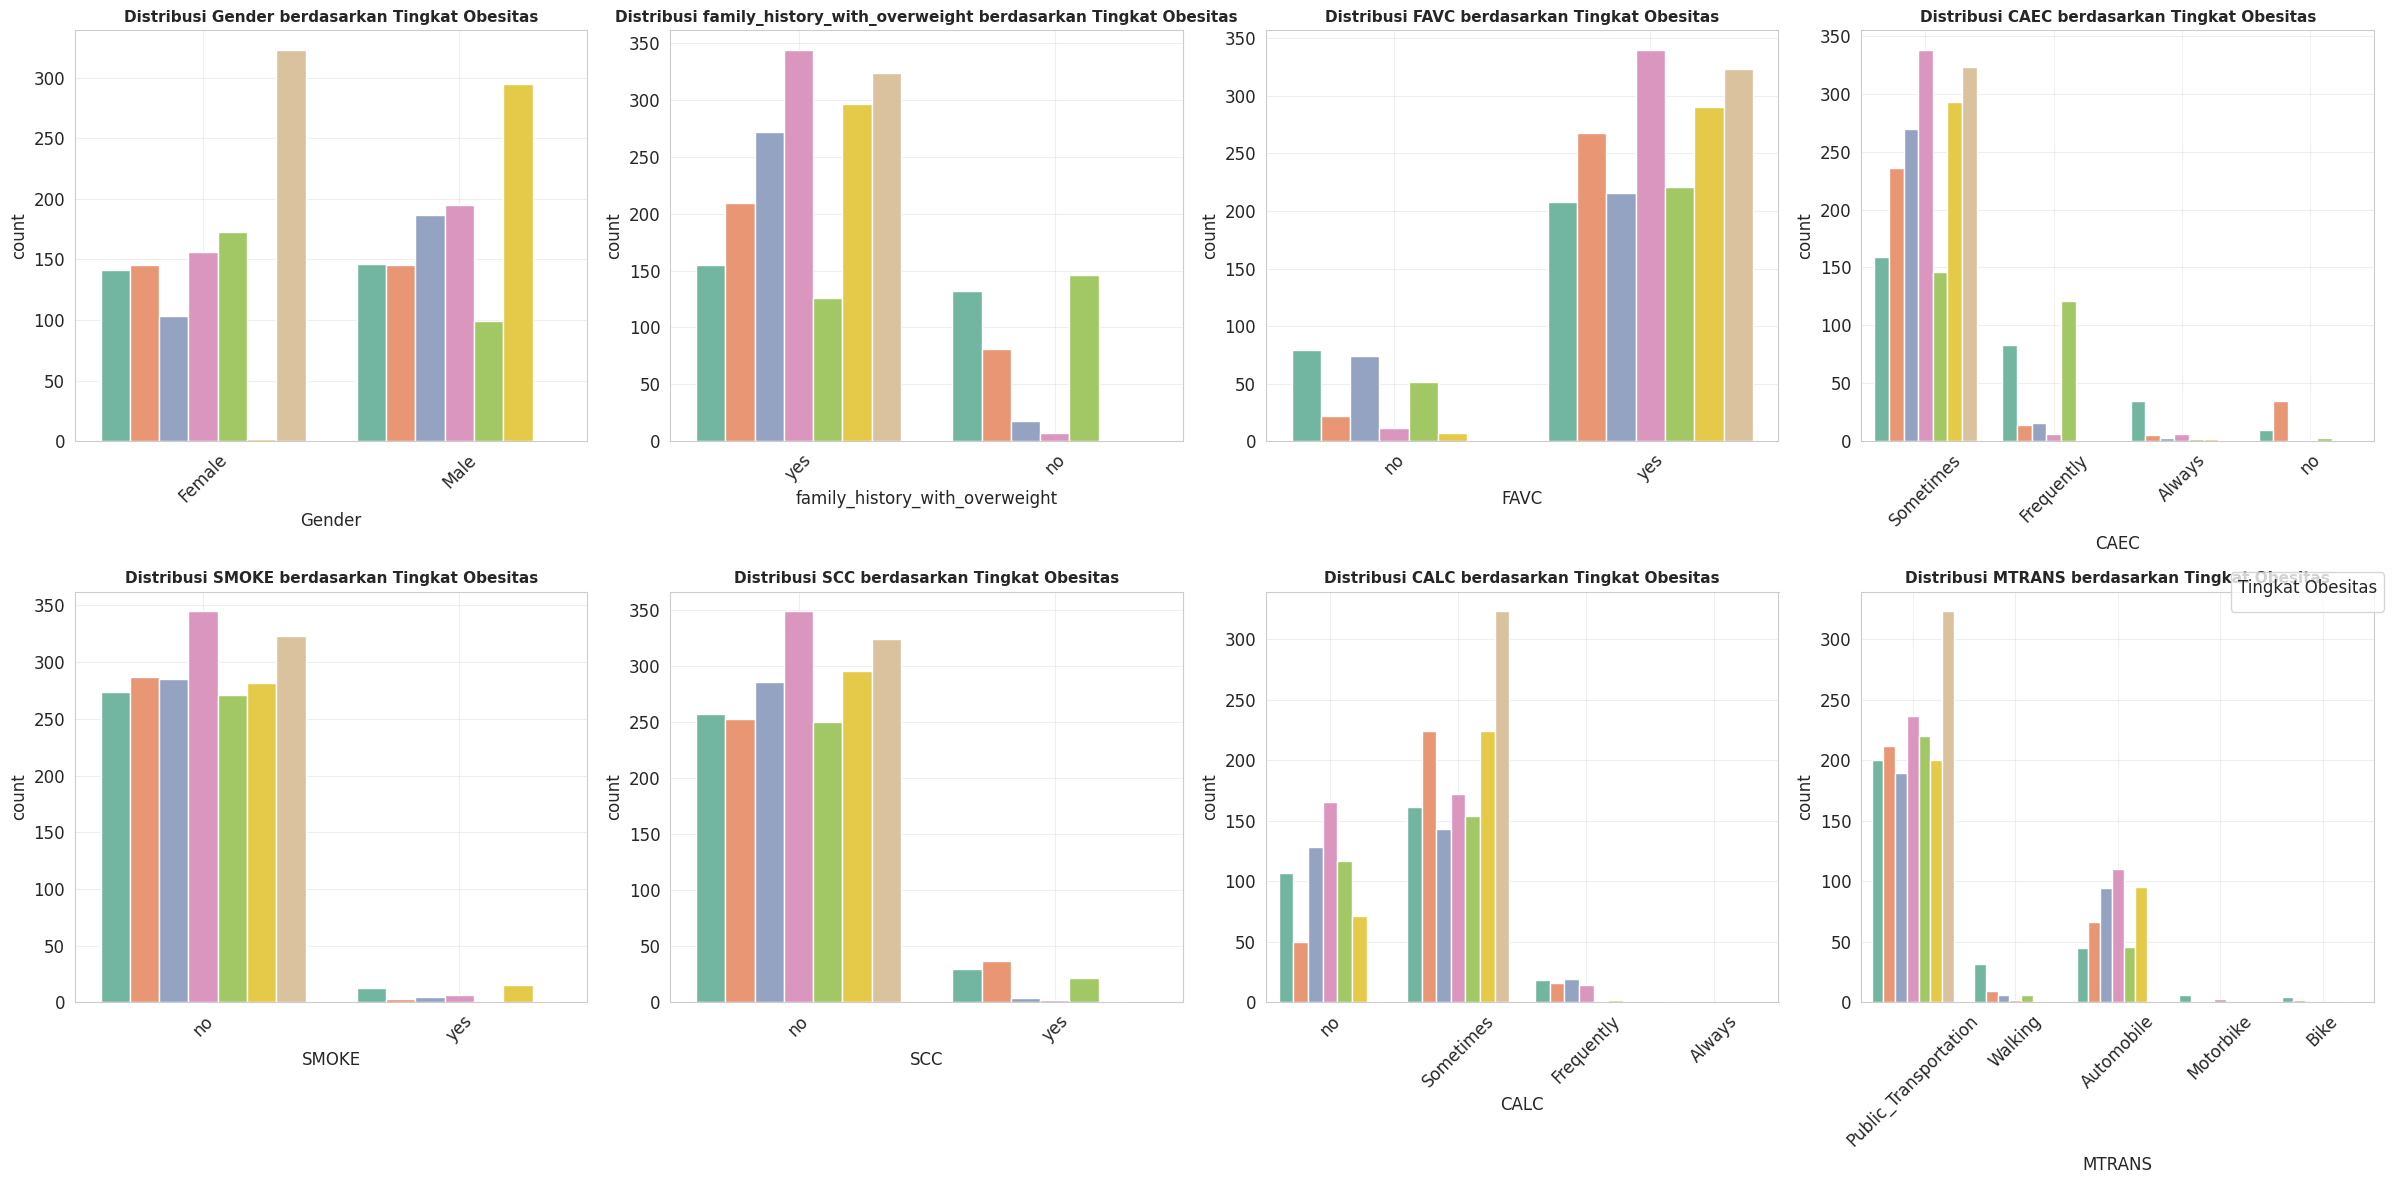

In [ ]:
# 3.5 Analisis Fitur Kategorikal
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC',
                    'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df_obesity, x=col, hue='NObeyesdad', ax=axes[idx],
                 palette='Set2', legend=False)
    axes[idx].set_title(f'Distribusi {col} berdasarkan Tingkat Obesitas',
                        fontweight='bold', fontsize=11)
    axes[idx].set_xlabel(col)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

# Tambahkan legend di akhir
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.0, 0.5),
           title='Tingkat Obesitas')
plt.tight_layout()
plt.show()

4. Preprocessing Data

In [ ]:
# 4.1 Identifikasi Missing Values dan Duplikat
print("Missing values per kolom:")
print(df_obesity.isnull().sum())

print("\nJumlah data duplikat:", df_obesity.duplicated().sum())

Missing values per kolom:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Jumlah data duplikat: 24


In [ ]:
# 4.2 Pisahkan Fitur dan Target
X = df_obesity.drop('NObeyesdad', axis=1)
y = df_obesity['NObeyesdad']

In [ ]:
# 4.3 Identifikasi Kolom Numerik dan Kategorikal
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC',
                        'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

In [ ]:
# 4.4 Encoding Target (Label Encoding)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Mapping target ke numerik:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

Mapping target ke numerik:
Insufficient_Weight: 0
Normal_Weight: 1
Obesity_Type_I: 2
Obesity_Type_II: 3
Obesity_Type_III: 4
Overweight_Level_I: 5
Overweight_Level_II: 6


In [ ]:
# 4.5 Preprocessing Pipeline
# Untuk fitur kategorikal: One-Hot Encoding
# Untuk fitur numerik: StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

In [ ]:
# 4.6 Split Data Training dan Testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                                    random_state=42, stratify=y_encoded)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 1688
Jumlah data testing: 423


In [ ]:
# 4.7 Transformasi Data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Bentuk data training setelah preprocessing: {X_train_preprocessed.shape}")
print(f"Bentuk data testing setelah preprocessing: {X_test_preprocessed.shape}")

# Simpan preprocessor untuk digunakan di Gradio
joblib.dump(preprocessor, 'preprocessor_obesity.pkl')
print("Preprocessor berhasil disimpan!")

Bentuk data training setelah preprocessing: (1688, 23)
Bentuk data testing setelah preprocessing: (423, 23)
Preprocessor berhasil disimpan!


5. Pemilihan Algoritma (Supervised Learning)

Algoritma yang akan digunakan:
1. Logistic Regression: Baseline model yang sederhana dan interpretable.
2. Decision Tree: Model yang mudah diinterpretasikan dan dapat menangkap non-linear.
3. Random Forest: Ensemble method yang robust dan akurat.
4. K-Nearest Neighbors (KNN): Berbasis jarak, cocok untuk pola yang kompleks.
5. Gradient Boosting: Ensemble yang powerful untuk meningkatkan akurasi.
6. Support Vector Machine (SVM): Efektif untuk dataset dengan dimensi tinggi.

Alasan pemilihan:
- Logistic Regression: Memberikan baseline performa yang baik dan cepat.
- Decision Tree: Dapat menangkap interaksi non-linear antar fitur.
- Random Forest: Mengurangi overfitting dengan menggabungkan banyak tree.
- KNN: Sederhana dan efektif untuk data dengan pola yang jelas.
- Gradient Boosting: Mampu meningkatkan performa secara bertahap.
- SVM: Handal untuk klasifikasi dengan batas keputusan yang kompleks.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

6. Training dan Evaluasi Model


Training Model: Logistic Regression
Accuracy: 0.8794
Precision (weighted): 0.8780
Recall (weighted): 0.8794
F1-Score (weighted): 0.8782
Cross-validation (5-fold): 0.8815 (+/- 0.0176)

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.96        54
      Normal_Weight       0.83      0.76      0.79        58
     Obesity_Type_I       0.89      0.91      0.90        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.74      0.74      0.74        58
Overweight_Level_II       0.80      0.78      0.79        58

           accuracy                           0.88       423
          macro avg       0.88      0.88      0.88       423
       weighted avg       0.88      0.88      0.88       423



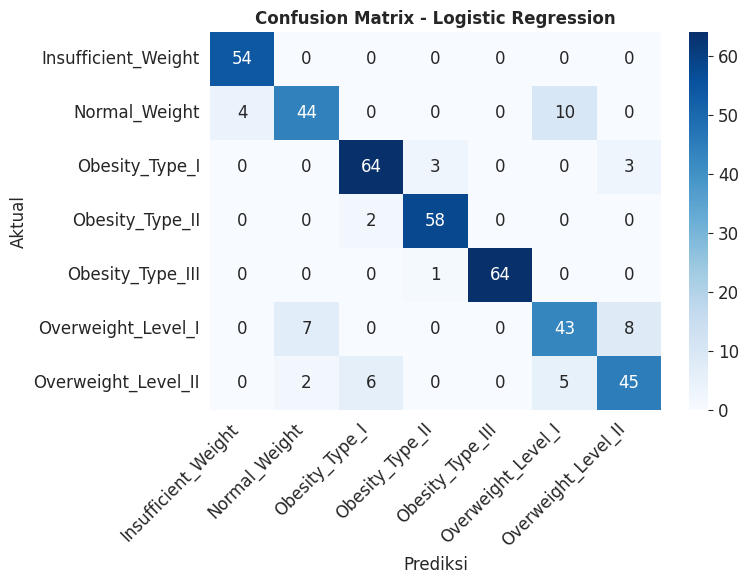


Training Model: Decision Tree
Accuracy: 0.9385
Precision (weighted): 0.9415
Recall (weighted): 0.9385
F1-Score (weighted): 0.9389
Cross-validation (5-fold): 0.9313 (+/- 0.0209)

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.87      0.92        54
      Normal_Weight       0.83      0.95      0.89        58
     Obesity_Type_I       0.94      0.94      0.94        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.95      0.90      0.92        58
Overweight_Level_II       0.92      0.97      0.94        58

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



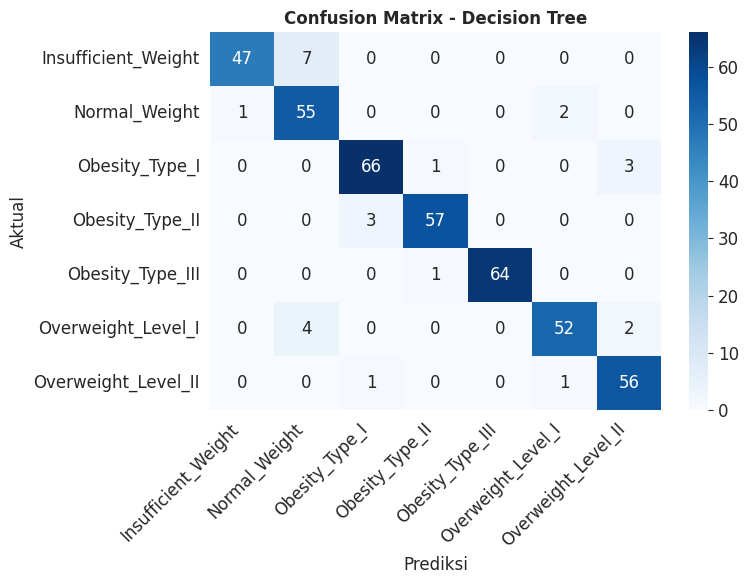


Training Model: Random Forest
Accuracy: 0.9409
Precision (weighted): 0.9473
Recall (weighted): 0.9409
F1-Score (weighted): 0.9424
Cross-validation (5-fold): 0.9449 (+/- 0.0155)

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.76      0.93      0.84        58
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.92      0.84      0.88        58
Overweight_Level_II       0.98      0.95      0.96        58

           accuracy                           0.94       423
          macro avg       0.95      0.94      0.94       423
       weighted avg       0.95      0.94      0.94       423



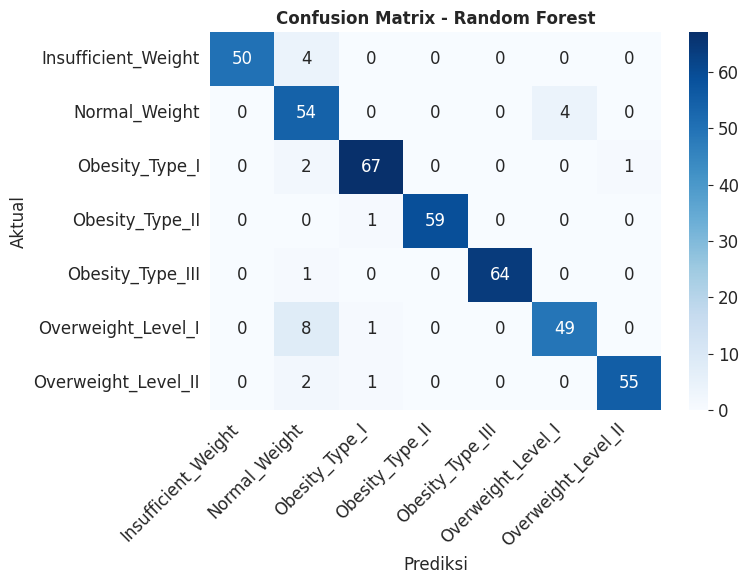


Training Model: K-Nearest Neighbors
Accuracy: 0.8416
Precision (weighted): 0.8393
Recall (weighted): 0.8416
F1-Score (weighted): 0.8350
Cross-validation (5-fold): 0.8205 (+/- 0.0167)

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.81      0.94      0.87        54
      Normal_Weight       0.78      0.53      0.63        58
     Obesity_Type_I       0.80      0.96      0.87        70
    Obesity_Type_II       0.95      0.97      0.96        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.78      0.67      0.72        58
Overweight_Level_II       0.76      0.78      0.77        58

           accuracy                           0.84       423
          macro avg       0.84      0.84      0.83       423
       weighted avg       0.84      0.84      0.84       423



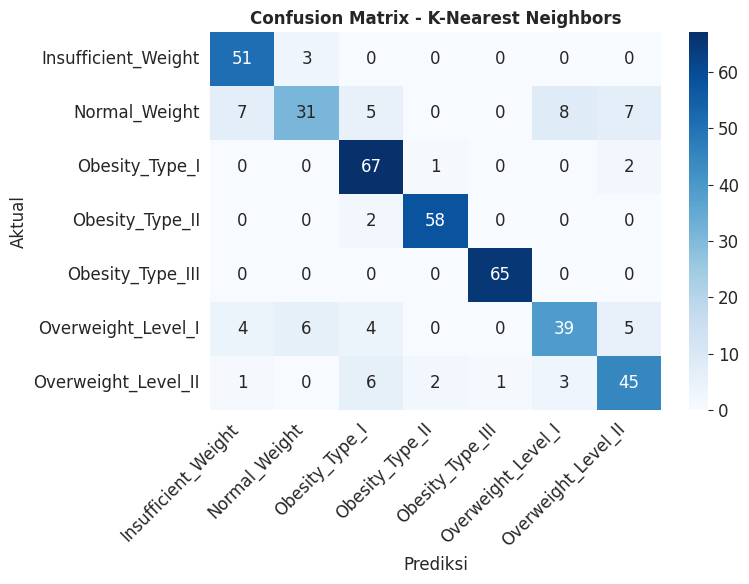


Training Model: Gradient Boosting
Accuracy: 0.9456
Precision (weighted): 0.9487
Recall (weighted): 0.9456
F1-Score (weighted): 0.9463
Cross-validation (5-fold): 0.9597 (+/- 0.0110)

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.91      0.94        54
      Normal_Weight       0.82      0.95      0.88        58
     Obesity_Type_I       0.97      0.94      0.96        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.88      0.89        58
Overweight_Level_II       0.97      0.97      0.97        58

           accuracy                           0.95       423
          macro avg       0.95      0.94      0.94       423
       weighted avg       0.95      0.95      0.95       423



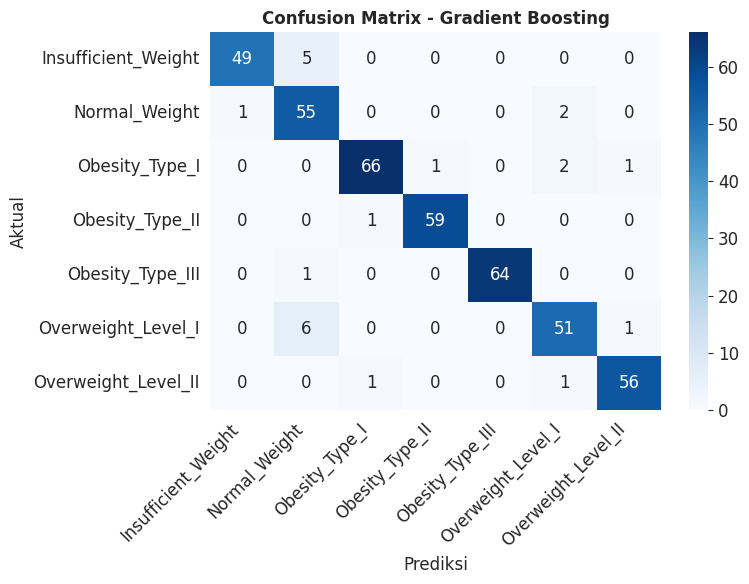


Training Model: SVM
Accuracy: 0.9314
Precision (weighted): 0.9338
Recall (weighted): 0.9314
F1-Score (weighted): 0.9320
Cross-validation (5-fold): 0.9254 (+/- 0.0151)

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.80      0.90      0.85        58
     Obesity_Type_I       0.94      0.97      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.86      0.83      0.84        58
Overweight_Level_II       0.93      0.88      0.90        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



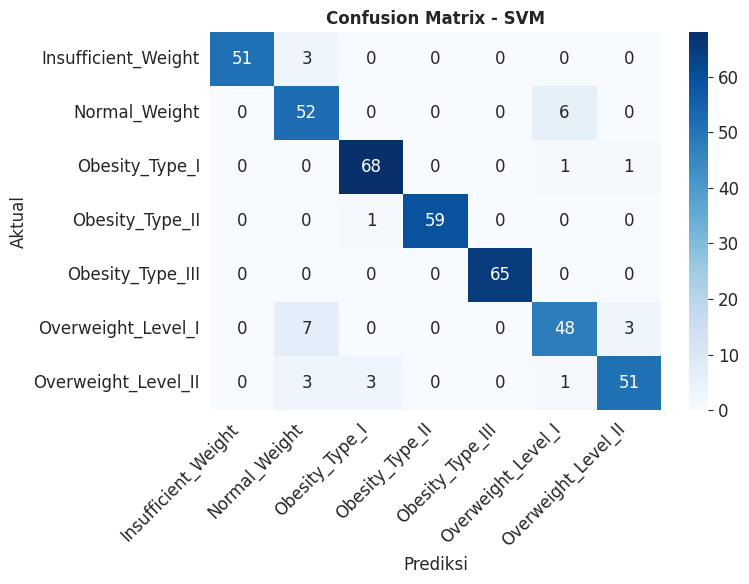

In [ ]:
# Pastikan seluruh pustaka evaluasi diimpor dengan benar agar tidak memicu NameError
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# Kamus/Dictionary untuk menyimpan hasil evaluasi
results = {}
best_model = None
best_f1 = 0
best_model_name = ""

# Pastikan variabel 'models', 'X_train_preprocessed', 'X_test_preprocessed',
# 'y_train', 'y_test', dan 'label_encoder' sudah didefinisikan di sel sebelumnya.

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training Model: {name}")
    print('='*60)

    try:
        # 1. Proses Training Model
        model.fit(X_train_preprocessed, y_train)

        # 2. Prediksi pada Data Testing
        y_pred = model.predict(X_test_preprocessed)

        # 3. Evaluasi Metrik Klasifikasi (Menggunakan rata-rata weighted sesuai metrik PDF)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # 4. Validasi Silang / Cross-Validation (5-fold)
        try:
            cv_scores = cross_val_score(model, X_train_preprocessed, y_train, cv=5, n_jobs=-1)
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
        except Exception as cv_error:
            cv_mean = np.nan
            cv_std = np.nan
            print(f"Cross-validation skipped untuk {name} karena: {str(cv_error)}")

        # 5. Penyimpanan Hasil Evaluasi ke Dictionary
        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'CV Mean': cv_mean if not np.isnan(cv_mean) else 0.0,
            'CV Std': cv_std if not np.isnan(cv_std) else 0.0,
            'Model': model
        }

        # 6. Menampilkan Hasil Evaluasi Teks
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision (weighted): {precision:.4f}")
        print(f"Recall (weighted): {recall:.4f}")
        print(f"F1-Score (weighted): {f1:.4f}")
        if not np.isnan(cv_mean):
            print(f"Cross-validation (5-fold): {cv_mean:.4f} (+/- {cv_std:.4f})")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

        # 7. Visualisasi Heatmap Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_encoder.classes_,
                    yticklabels=label_encoder.classes_)
        plt.title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
        plt.xlabel('Prediksi')
        plt.ylabel('Aktual')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # 8. Penentuan Model Terbaik Berdasarkan F1-Score
        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_model_name = name

    except Exception as e:
        print(f"Error pada model {name}: {str(e)}")
        continue


PERBANDINGAN PERFORMA SEMUA MODEL
                     Accuracy Precision    Recall  F1-Score   CV Mean
Logistic Regression  0.879433  0.877979  0.879433  0.878219  0.881518
Decision Tree        0.938534  0.941505  0.938534  0.938913   0.93127
Random Forest        0.940898   0.94728  0.940898  0.942424  0.944916
K-Nearest Neighbors  0.841608  0.839336  0.841608  0.835009  0.820508
Gradient Boosting    0.945626  0.948687  0.945626  0.946269  0.959714
SVM                  0.931442  0.933823  0.931442   0.93199  0.925356




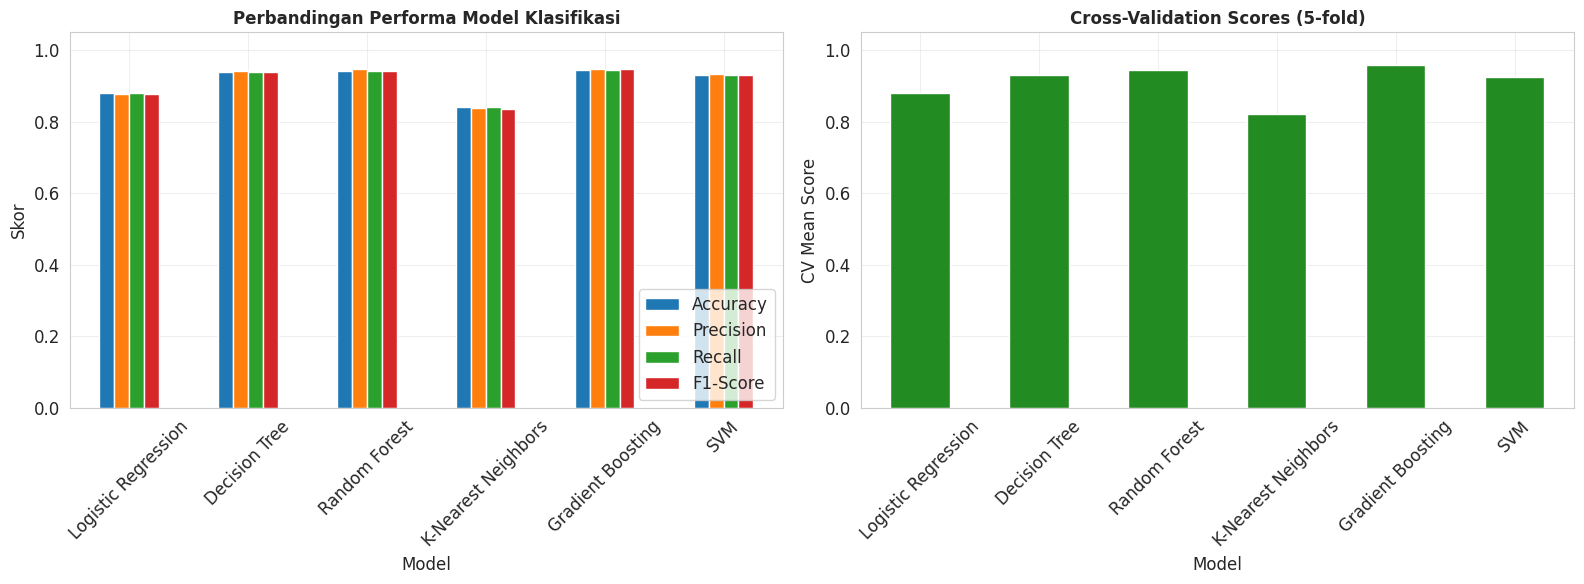


MODEL TERBAIK: Gradient Boosting
F1-Score Tertinggi: 0.9463


In [ ]:
print("\n" + "="*80)
print("PERBANDINGAN PERFORMA SEMUA MODEL")
print("="*80)

if results:
    # Mengonversi dictionary hasil menjadi DataFrame
    results_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean']]
    results_df = results_df.round(4)

    # Menggunakan print standar dikombinasikan dengan DataFrame agar kompatibel di skrip .py maupun .ipynb
    print(results_df.to_string())
    print("\n")

    # 9. Visualisasi Komparasi Performa Akhir
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Bar plot untuk metrik evaluasi utama
    results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax1)
    ax1.set_title('Perbandingan Performa Model Klasifikasi', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Model')
    ax1.set_ylabel('Skor')
    ax1.legend(loc='lower right')
    ax1.set_ylim(0.0, 1.05) # Mengubah range y-axis menjadi 0-1 agar lebih representatif visualnya
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Bar plot untuk nilai Cross-Validation
    results_df[['CV Mean']].plot(kind='bar', ax=ax2, color='forestgreen', legend=False)
    ax2.set_title('Cross-Validation Scores (5-fold)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Model')
    ax2.set_ylabel('CV Mean Score')
    ax2.set_ylim(0.0, 1.05)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # 10. Output Informasi Model Terbaik
    print(f"\n{'='*60}")
    print(f"MODEL TERBAIK: {best_model_name}")
    print(f"F1-Score Tertinggi: {best_f1:.4f}")
    print('='*60)
else:
    print("Tidak ada model yang berhasil dilatih dan dievaluasi!")

In [ ]:
if best_model is not None:
    joblib.dump(best_model, 'best_model_obesity.pkl')
    joblib.dump(label_encoder, 'label_encoder_obesity.pkl')
    print(f"\n[SUKSES] Model terbaik ({best_model_name}) dan label encoder berhasil disimpan untuk aplikasi Gradio!")
else:
    print("\n[GAGAL] Tidak ada model valid yang berhasil disimpan.")


[SUKSES] Model terbaik (Gradient Boosting) dan label encoder berhasil disimpan untuk aplikasi Gradio!


7. SIMPAN MODEL TERBAIK

In [ ]:
import joblib

joblib.dump(best_model, "best_model_obesity.pkl")
joblib.dump(preprocessor, "preprocessor_obesity.pkl")
joblib.dump(label_encoder, "label_encoder_obesity.pkl")

print("Semua file berhasil disimpan!")

Semua file berhasil disimpan!


7. GRADIO - OBESITY PREDICTION SYSTEM

In [ ]:
import pandas as pd
import joblib
import gradio as gr

# Load model
model = joblib.load("best_model_obesity.pkl")
preprocessor = joblib.load("preprocessor_obesity.pkl")
label_encoder = joblib.load("label_encoder_obesity.pkl")

In [ ]:
def predict_obesity(
    Gender,
    Age,
    Height,
    Weight,
    family_history_with_overweight,
    FAVC,
    FCVC,
    NCP,
    CAEC,
    SMOKE,
    CH2O,
    SCC,
    FAF,
    TUE,
    CALC,
    MTRANS
):

    data = pd.DataFrame({

        "Gender":[Gender],
        "Age":[Age],
        "Height":[Height],
        "Weight":[Weight],
        "family_history_with_overweight":[family_history_with_overweight],
        "FAVC":[FAVC],
        "FCVC":[FCVC],
        "NCP":[NCP],
        "CAEC":[CAEC],
        "SMOKE":[SMOKE],
        "CH2O":[CH2O],
        "SCC":[SCC],
        "FAF":[FAF],
        "TUE":[TUE],
        "CALC":[CALC],
        "MTRANS":[MTRANS]

    })

    data = preprocessor.transform(data)

    pred = model.predict(data)

    hasil = label_encoder.inverse_transform(pred)[0]

    if hasattr(model,"predict_proba"):

        prob = model.predict_proba(data).max()*100

        return hasil,f"{prob:.2f}%"

    else:

        return hasil,"-"

In [ ]:
demo = gr.Interface(

    fn=predict_obesity,

    inputs=[

        gr.Dropdown(["Male","Female"],label="Gender"),

        gr.Number(label="Age"),

        gr.Number(label="Height"),

        gr.Number(label="Weight"),

        gr.Dropdown(["yes","no"],label="Family History"),

        gr.Dropdown(["yes","no"],label="High Calorie Food"),

        gr.Slider(1,3,step=0.1,label="FCVC"),

        gr.Slider(1,4,step=0.1,label="NCP"),

        gr.Dropdown(["no","Sometimes","Frequently","Always"],label="CAEC"),

        gr.Dropdown(["yes","no"],label="Smoke"),

        gr.Slider(1,3,step=0.1,label="CH2O"),

        gr.Dropdown(["yes","no"],label="SCC"),

        gr.Slider(0,3,step=0.1,label="FAF"),

        gr.Slider(0,2,step=0.1,label="TUE"),

        gr.Dropdown(["no","Sometimes","Frequently","Always"],label="CALC"),

        gr.Dropdown(
            [
                "Automobile",
                "Motorbike",
                "Bike",
                "Public_Transportation",
                "Walking"
            ],
            label="Transportation"
        )

    ],

    outputs=[

        gr.Textbox(label="Prediction"),

        gr.Textbox(label="Confidence")

    ],

    title="Obesity Prediction",

    description="Prediksi Tingkat Obesitas Menggunakan Machine Learning"

)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2a760cf3528eeccba5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


7. Pelatihan File ( train.py)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import kagglehub

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def main():
    print("="*80)
    print("1. MEMUAT DATASET")
    print("="*80)

    # Download dataset via kagglehub
    path = kagglehub.dataset_download("adeniranstephen/obesity-prediction-dataset")
    file_path = f"{path}/ObesityDataSet_raw_and_data_sinthetic.csv"

    df_obesity = pd.read_csv(file_path)
    print(f"Dataset berhasil dimuat: {df_obesity.shape[0]} baris, {df_obesity.shape[1]} kolom\n")

    # 2. PEMISAHAN FITUR & TARGET
    X = df_obesity.drop('NObeyesdad', axis=1)
    y = df_obesity['NObeyesdad']

    numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
    categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC',
                            'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

    # Encode Target
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Preprocessing Pipeline (Numerical -> Scaling, Categorical -> OneHotEncoding)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
        ]
    )

    # Train Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Fit & Transform Data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)

    # 3. INISIALISASI MODEL
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42, probability=True)
    }

    results = {}
    best_model = None
    best_f1 = 0.0
    best_model_name = ""

    print("="*80)
    print("2. TRAINING DAN EVALUASI MODEL")
    print("="*80)

    for name, model in models.items():
        model.fit(X_train_preprocessed, y_train)
        y_pred = model.predict(X_test_preprocessed)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        cv_scores = cross_val_score(model, X_train_preprocessed, y_train, cv=5, n_jobs=-1)
        cv_mean = cv_scores.mean()

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'CV Mean': cv_mean
        }

        print(f"Model: {name:<20} | Acc: {accuracy:.4f} | F1: {f1:.4f} | CV: {cv_mean:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_model_name = name

    print("\n" + "="*80)
    print(f"MODEL TERBAIK: {best_model_name} (F1-Score: {best_f1:.4f})")
    print("="*80)

    # 4. SIMPAN ARTEFAK
    joblib.dump(preprocessor, 'preprocessor_obesity.pkl')
    joblib.dump(best_model, 'best_model_obesity.pkl')
    joblib.dump(label_encoder, 'label_encoder_obesity.pkl')
    print("\n[SUKSES] Seluruh artefak model (.pkl) berhasil disimpan!")

if __name__ == "__main__":
    main()

1. MEMUAT DATASET
Using Colab cache for faster access to the 'obesity-prediction-dataset' dataset.
Dataset berhasil dimuat: 2111 baris, 17 kolom

2. TRAINING DAN EVALUASI MODEL
Model: Logistic Regression  | Acc: 0.8794 | F1: 0.8782 | CV: 0.8815
Model: Decision Tree        | Acc: 0.9385 | F1: 0.9389 | CV: 0.9313
Model: Random Forest        | Acc: 0.9409 | F1: 0.9424 | CV: 0.9449
Model: K-Nearest Neighbors  | Acc: 0.8416 | F1: 0.8350 | CV: 0.8205
Model: Gradient Boosting    | Acc: 0.9456 | F1: 0.9463 | CV: 0.9597
Model: SVM                  | Acc: 0.9314 | F1: 0.9320 | CV: 0.9254

MODEL TERBAIK: Gradient Boosting (F1-Score: 0.9463)

[SUKSES] Seluruh artefak model (.pkl) berhasil disimpan!


8. File Aplikasi Gradio ( app.py)

In [ ]:
import gradio as gr
import joblib
import pandas as pd
import numpy as np

# Load model dan komponen penunjang
try:
    preprocessor = joblib.load('preprocessor_obesity.pkl')
    model = joblib.load('best_model_obesity.pkl')
    label_encoder = joblib.load('label_encoder_obesity.pkl')
    print("[INFO] Artefak model berhasil dimuat!")
except Exception as e:
    print(f"[ERROR] Gagal memuat file .pkl: {e}")

def predict_obesity(
    gender, age, height, weight, family_history, favc,
    fcvc, ncp, caec, smoke, ch2o, scc, faf, tue, calc, mtrans
):
    # Buat DataFrame dari input user
    input_data = pd.DataFrame([{
        'Gender': gender,
        'Age': float(age),
        'Height': float(height),
        'Weight': float(weight),
        'family_history_with_overweight': family_history,
        'FAVC': favc,
        'FCVC': float(fcvc),
        'NCP': float(ncp),
        'CAEC': caec,
        'SMOKE': smoke,
        'CH2O': float(ch2o),
        'SCC': scc,
        'FAF': float(faf),
        'TUE': float(tue),
        'CALC': calc,
        'MTRANS': mtrans
    }])

    # Preprocessing & Prediksi
    input_preprocessed = preprocessor.transform(input_data)
    prediction_numeric = model.predict(input_preprocessed)[0]
    prediction_label = label_encoder.inverse_transform([prediction_numeric])[0]

    # Hitung probabilitas tiap kelas
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(input_preprocessed)[0]
        prob_dict = {
            label_encoder.classes_[i].replace("_", " "): float(probabilities[i])
            for i in range(len(label_encoder.classes_))
        }
        return prediction_label.replace("_", " "), prob_dict

    return prediction_label.replace("_", " "), {}

# Desain Interface
with gr.Blocks(theme=gr.themes.Soft(), title="Sistem Prediksi Obesitas") as demo:
    gr.Markdown(
        """
        # 🩺 Prediksi Tingkat Obesitas
        Masukkan data demografi, kebiasaan makan, dan tingkat aktivitas harian Anda untuk memprediksi kategori obesitas.
        """
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 👤 Data Fisik & Demografi")
            gender = gr.Dropdown(choices=["Female", "Male"], value="Male", label="Jenis Kelamin")
            age = gr.Slider(minimum=10, maximum=100, value=25, step=1, label="Usia (Tahun)")
            height = gr.Slider(minimum=1.00, maximum=2.50, value=1.70, step=0.01, label="Tinggi Badan (Meter)")
            weight = gr.Slider(minimum=30.0, maximum=200.0, value=70.0, step=0.5, label="Berat Badan (Kg)")
            family_history = gr.Radio(choices=["yes", "no"], value="yes", label="Riwayat Obesitas Keluarga")

        with gr.Column():
            gr.Markdown("### 🥗 Pola Makan")
            favc = gr.Radio(choices=["yes", "no"], value="yes", label="Sering Makan Tinggi Kalori (FAVC)")
            fcvc = gr.Slider(minimum=1, maximum=3, value=2, step=1, label="Frekuensi Makan Sayur (FCVC: 1-3)")
            ncp = gr.Slider(minimum=1, maximum=4, value=3, step=1, label="Frekuensi Makan Utama/Hari (NCP: 1-4)")
            caec = gr.Dropdown(choices=["no", "Sometimes", "Frequently", "Always"], value="Sometimes", label="Cemilan di Luar Jam Makan (CAEC)")
            ch2o = gr.Slider(minimum=1, maximum=3, value=2, step=1, label="Konsumsi Air Harian/Liter (CH2O: 1-3)")
            scc = gr.Radio(choices=["yes", "no"], value="no", label="Memonitor Asupan Kalori (SCC)")

        with gr.Column():
            gr.Markdown("### 🏃 Gaya Hidup & Transportasi")
            faf = gr.Slider(minimum=0, maximum=3, value=1, step=1, label="Frekuensi Olahraga/Minggu (FAF: 0-3)")
            tue = gr.Slider(minimum=0, maximum=2, value=1, step=1, label="Waktu Penggunaan Gadget/Hari (TUE: 0-2)")
            smoke = gr.Radio(choices=["yes", "no"], value="no", label="Merokok (SMOKE)")
            calc = gr.Dropdown(choices=["no", "Sometimes", "Frequently", "Always"], value="Sometimes", label="Konsumsi Alkohol (CALC)")
            mtrans = gr.Dropdown(
                choices=["Automobile", "Motorbike", "Bike", "Public_Transportation", "Walking"],
                value="Public_Transportation",
                label="Moda Transportasi Utama"
            )

    btn_predict = gr.Button("🔍 Prediksi Sekarang", variant="primary")

    with gr.Row():
        with gr.Column():
            out_label = gr.Textbox(label="Kategori Hasil Prediksi", interactive=False)
            out_probs = gr.Label(label="Probabilitas Masing-masing Kelas")

    btn_predict.click(
        fn=predict_obesity,
        inputs=[gender, age, height, weight, family_history, favc, fcvc, ncp, caec, smoke, ch2o, scc, faf, tue, calc, mtrans],
        outputs=[out_label, out_probs]
    )

if __name__ == "__main__":
    demo.launch()

[INFO] Artefak model berhasil dimuat!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c340fad6dace267389.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
